In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [71]:
amazon_data = pd.read_csv("./dataset/portfolio_data.csv")

In [72]:
amazon_data = amazon_data.drop(["DPZ", "BTC", "NFLX"], axis=1)

In [73]:
amazon_data.head()

,Date,AMZN
0,5/1/2013,248.229996
1,5/2/2013,252.550003
2,5/3/2013,258.049988
3,5/6/2013,255.720001
4,5/7/2013,257.730011


In [74]:
amazon_data.shape

(1520, 2)

In [75]:
amazon_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1520 entries, 0 to 1519
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1520 non-null   str    
 1   AMZN    1520 non-null   float64
dtypes: float64(1), str(1)
memory usage: 23.9 KB


In [76]:
amazon_data.isnull().sum()

Date    0
AMZN    0
dtype: int64

In [77]:
amazon_data.duplicated().sum()

np.int64(0)

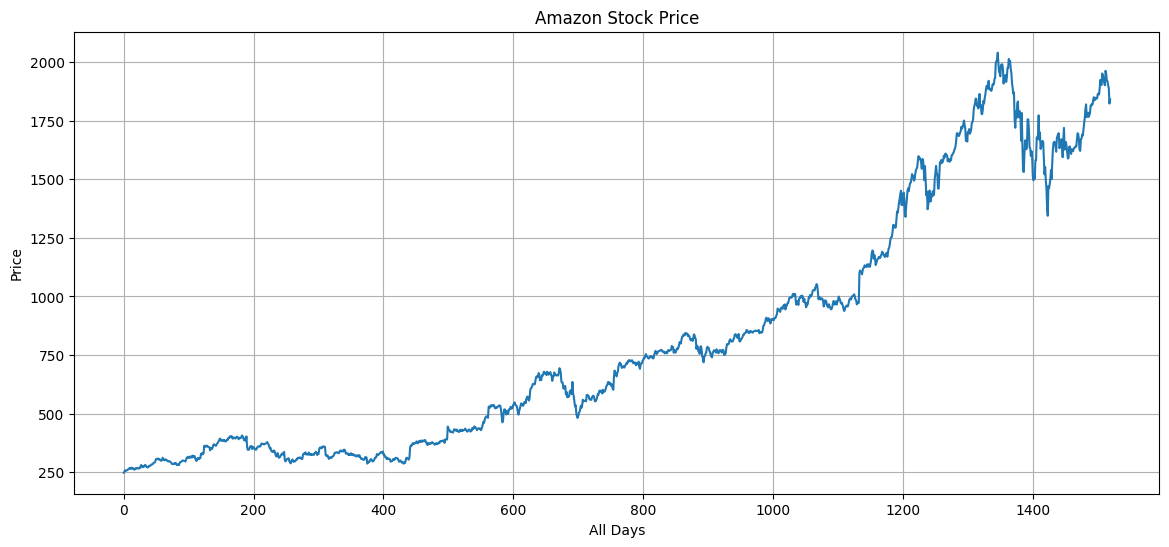

In [78]:
plt.figure(figsize=(14, 6))
plt.plot(amazon_data['AMZN'])
plt.title("Amazon Stock Price")
plt.xlabel("All Days")
plt.ylabel("Price")
plt.grid()
plt.show()

##### input: N days that we already know the values
##### output: y days that we want to predict

In [79]:
amazon_price = amazon_data["AMZN"].values
print(type(amazon_price))

X = []
y = []
input_days = 30
output_days = 1
print(f"Expected generated data length should be: {len(amazon_price) - input_days - output_days + 1}")

counter = 0
for index in range(len(amazon_price) - input_days - output_days + 1):
    x_start_index = index
    x_end_index = index + input_days

    X.append(amazon_price[x_start_index : x_end_index])
    y.append(amazon_price[x_end_index])

    counter += 1
    if counter < 10:
        print(f"x_start_index: {x_start_index} - x_end_index: {x_end_index - output_days} - y_index: {x_end_index}")

<class 'numpy.ndarray'>
Expected generated data length should be: 1490
x_start_index: 0 - x_end_index: 29 - y_index: 30
x_start_index: 1 - x_end_index: 30 - y_index: 31
x_start_index: 2 - x_end_index: 31 - y_index: 32
x_start_index: 3 - x_end_index: 32 - y_index: 33
x_start_index: 4 - x_end_index: 33 - y_index: 34
x_start_index: 5 - x_end_index: 34 - y_index: 35
x_start_index: 6 - x_end_index: 35 - y_index: 36
x_start_index: 7 - x_end_index: 36 - y_index: 37
x_start_index: 8 - x_end_index: 37 - y_index: 38


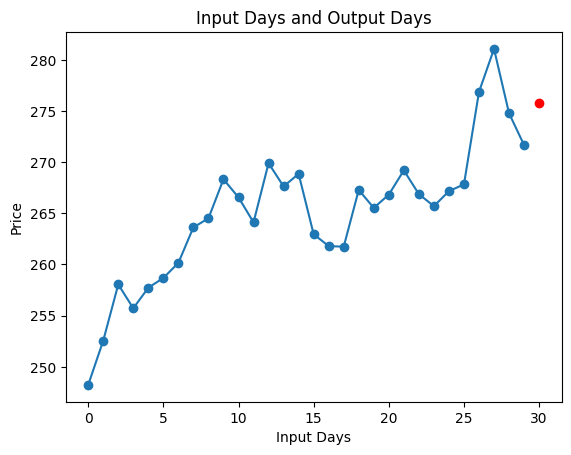

In [80]:
sample_index = 0
plt.plot(X[sample_index], marker= 'o')
plt.plot(input_days, y[sample_index], 'ro')
plt.xlabel("Input Days")
plt.ylabel("Price")
plt.title("Input Days and Output Days")
plt.show()

### Train & Test split

In [81]:
# train_size = int(len(X)* 0.8)

# X_train = X[:train_size]
# X_test = X[train_size:]

# y_train = y[:train_size]
# y_test = y[train_size:]

In [82]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [83]:
1490 * 0.2

298.0

### pre-processing

In [84]:
from sklearn.preprocessing import MinMaxScaler

feature_scaler = MinMaxScaler()
X_train_norm = feature_scaler.fit_transform(X_train)
X_test_norm = feature_scaler.transform(X_test)

target_scaler = MinMaxScaler()
y_train_norm = target_scaler.fit_transform(np.reshape(y_train, (-1, 1)))
y_test_norm = target_scaler.transform(np.reshape(y_test, (-1, 1)))

In [85]:
print(f"Input Days: {input_days} - Output Days: {output_days}")
print(f"X_train Shape: {X_train_norm.shape} - X_test Shape: {X_test_norm.shape}")
print(f"y_train Shape: {y_train_norm.shape} - y_test Shape: {y_test_norm.shape}")

Input Days: 30 - Output Days: 1
X_train Shape: (1192, 30) - X_test Shape: (298, 30)
y_train Shape: (1192, 1) - y_test Shape: (298, 1)


### 1.Linear Regression

In [86]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()
linear_model.fit(X_train_norm, y_train_norm)
linear_pred = linear_model.predict(X_test_norm)

In [87]:
print(f"linear Predicted Shape: {linear_pred.shape}")

linear Predicted Shape: (298, 1)


In [88]:
selected_index = 5

selected_x = X_test_norm[selected_index]
selected_y = y_test_norm[selected_index]
selected_pred = linear_pred[selected_index]

print(f"Selected X: {selected_x}")
print(f"Selected y: {selected_y}")
print(f"Selected predict: {selected_pred}")

Selected X: [0.04688267 0.0629619  0.05742829 0.05997343 0.05800378 0.06005245
 0.05554837 0.05456274 0.05461522 0.05312273 0.04602396 0.04982085
 0.05211024 0.0493821  0.05311328 0.05943401 0.06042965 0.05874776
 0.05603784 0.05470186 0.05759078 0.06101483 0.06350279 0.06520991
 0.06744754 0.07100041 0.06984165 0.06447511 0.0646495  0.06437899]
Selected y: [0.0657697]
Selected predict: [0.06407555]


In [89]:
print("Train Linear:", linear_model.score(X_train_norm, y_train_norm))
print("Test Linear:", linear_model.score(X_test_norm, y_test_norm))

Train Linear: 0.9987705395038543
Test Linear: 0.998504066955186


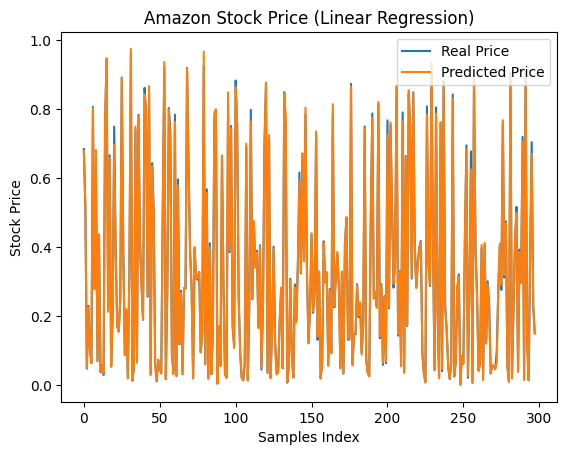

In [90]:
plt.plot(y_test_norm, label="Real Price")
plt.plot(linear_pred, label="Predicted Price")
plt.title("Amazon Stock Price (Linear Regression)")
plt.xlabel("Samples Index")
plt.ylabel("Stock Price")
plt.legend(loc='upper right')
plt.show()

### 2.Support Vector Regression

In [91]:
from sklearn.svm import SVR

svr_model = SVR(C=100, kernel="linear") #epsilon=1, gamma="scale"
svr_model.fit(X_train_norm, y_train_norm)
svr_pred = svr_model.predict(X_test_norm)

e:\Python Git\ML\breast_cancer_classification\.venv\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [92]:
print("Train SVR:", svr_model.score(X_train_norm, y_train_norm))
print("Test SVR:", svr_model.score(X_test_norm, y_test_norm))

Train SVR: 0.9724156843677835
Test SVR: 0.9716543657748661


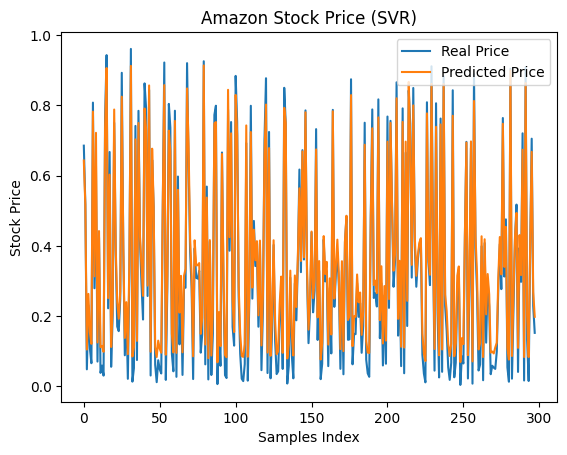

In [93]:
plt.plot(y_test_norm, label="Real Price")
plt.plot(svr_pred, label="Predicted Price")
plt.title("Amazon Stock Price (SVR)")
plt.xlabel("Samples Index")
plt.ylabel("Stock Price")
plt.legend(loc='upper right')
plt.show()

### 3.Random Forest Regressor

In [94]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=200, max_depth=8, min_samples_leaf=5, random_state=42)
rf_model.fit(X_train_norm, y_train_norm)
rf_pred = rf_model.predict(X_test_norm)

e:\Python Git\ML\breast_cancer_classification\.venv\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [95]:
print("Train RF:", rf_model.score(X_train_norm, y_train_norm))
print("Test RF:", rf_model.score(X_test_norm, y_test_norm))

Train RF: 0.999316558983787
Test RF: 0.9986108550945725


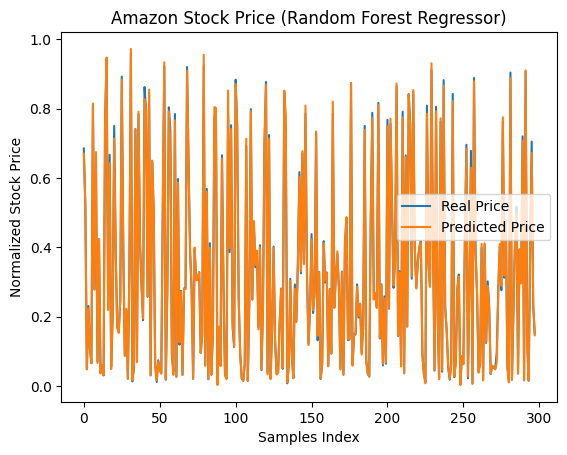

In [96]:
plt.plot(y_test_norm, label="Real Price")
plt.plot(rf_pred, label="Predicted Price")
plt.title("Amazon Stock Price (Random Forest Regressor)")
plt.xlabel("Samples Index")
plt.ylabel("Normalized Stock Price")
plt.legend()
plt.show()

### 4.Decision Tree Regressor

In [97]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(max_depth=5, min_samples_split=20, min_samples_leaf=10)
dt_model.fit(X_train_norm, y_train_norm)
dt_pred = dt_model.predict(X_test_norm)

In [98]:
print("Train DT:", dt_model.score(X_train_norm, y_train_norm))
print("Test DT:", dt_model.score(X_test_norm, y_test_norm))

Train DT: 0.9983738946825268
Test DT: 0.9976436409415425


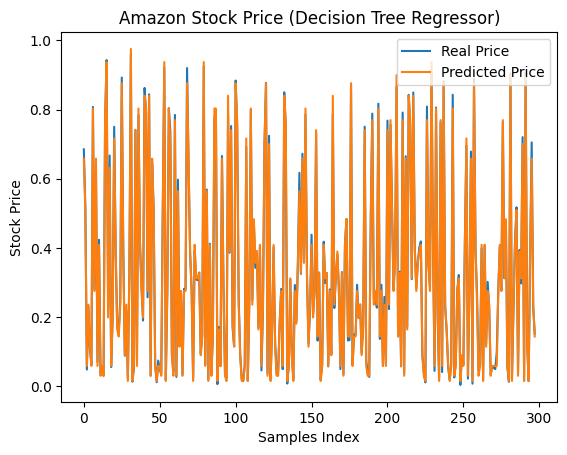

In [99]:
plt.plot(y_test_norm, label="Real Price")
plt.plot(dt_pred, label="Predicted Price")
plt.title("Amazon Stock Price (Decision Tree Regressor)")
plt.xlabel("Samples Index")
plt.ylabel("Stock Price")
plt.legend(loc='upper right')
plt.show()

### 5.KNeighbors Regressor

In [100]:
from sklearn.neighbors import KNeighborsRegressor

knn_model = KNeighborsRegressor()
knn_model.fit(X_train_norm, y_train_norm)
knn_pred = knn_model.predict(X_test_norm)

In [101]:
print("Train KNN:", knn_model.score(X_train_norm, y_train_norm))
print("Test KNN:", knn_model.score(X_test_norm, y_test_norm))

Train KNN: 0.999014481907839
Test KNN: 0.9985288001259097


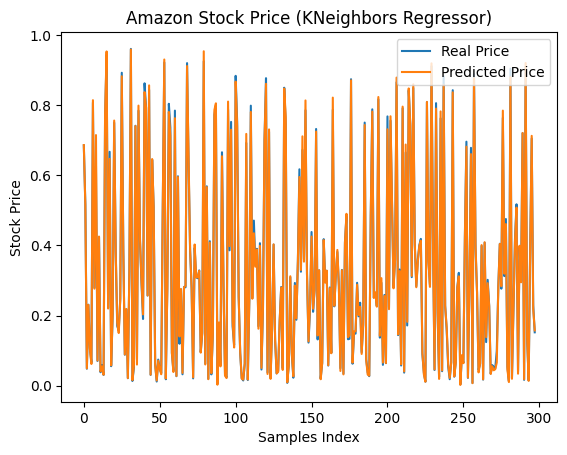

In [102]:
plt.plot(y_test_norm, label="Real Price")
plt.plot(knn_pred, label="Predicted Price")
plt.title("Amazon Stock Price (KNeighbors Regressor)")
plt.xlabel("Samples Index")
plt.ylabel("Stock Price")
plt.legend(loc='upper right')
plt.show()

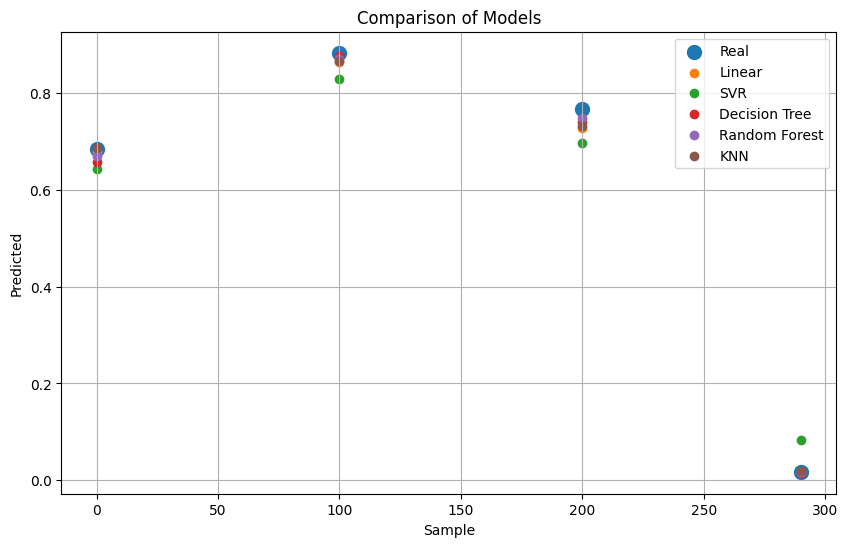

In [103]:
samples = [0, 100, 200, 290]
plt.figure(figsize=(10,6))
plt.scatter(samples,y_test_norm[samples],label="Real", s=100)
plt.scatter(samples,linear_pred[samples],label="Linear")
plt.scatter(samples,svr_pred[samples],label="SVR")
plt.scatter(samples,dt_pred[samples],label="Decision Tree")
plt.scatter(samples, rf_pred[samples], label="Random Forest")
plt.scatter(samples, knn_pred[samples], label="KNN")
plt.legend()
plt.grid()
plt.xlabel("Sample")
plt.ylabel("Predicted")
plt.title("Comparison of Models")
plt.show()